# Sydney Traffic Emissions: Source Data Analysis

This supplementary notebook explores the broader local Transport for NSW traffic datasets and supporting fleet and greenhouse-factor data. It complements `01_data_exploration.ipynb`, which analyzes Hana's curated modelling dataset. The notebook can run from either the repository root or the `notebooks` directory, and large hourly CSV files are read in chunks so they do not need to fit in memory.

The traffic data measures vehicle activity, not emissions directly. The final section separates useful model features from the extra information needed to construct a defensible emissions target.

In [1]:
from collections import defaultdict
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (11, 6), "axes.titleweight": "bold"})

def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "Dataset" / "Initial_dataset").exists():
            return candidate
    raise FileNotFoundError("Could not find Dataset/Initial_dataset above the current directory.")

PROJECT_ROOT = find_project_root()
INITIAL_DIR = PROJECT_ROOT / "Dataset" / "Initial_dataset"
EXTERNAL_DIR = PROJECT_ROOT / "Dataset" / "External_dataset" / "raw"

REFERENCE_FILE = INITIAL_DIR / "road_traffic_counts_station_reference.csv"
ANNUAL_FILE = INITIAL_DIR / "Traffic_Volume_Viewer_-_Data_for_All_Years.csv"
HOURLY_FILES = sorted(INITIAL_DIR.glob("road_traffic_counts_hourly_permanent*.csv"))
FLEET_FILE = EXTERNAL_DIR / "fleet" / "BITRE_Road_Vehicles_Australia_January_2025.xlsx"
FACTOR_FILE = EXTERNAL_DIR / "emission_factors" / "National_Greenhouse_Accounts_Factors_2025.xlsx"

# 2019 is a pre-pandemic baseline, 2020 captures disruption, and 2024-2025 are recent full years.
HOURLY_YEARS = [2019, 2020, 2024, 2025]
CHUNK_SIZE = 100_000
LAST_COMPLETE_YEAR = 2025
CLASS_LABELS = {0: "Unclassified vehicles", 2: "Light vehicles", 3: "Heavy vehicles"}
CLASS_COLORS = {"Unclassified vehicles": "#4C78A8", "Light vehicles": "#2A9D8F", "Heavy vehicles": "#E45756"}

print(f"Project root: {PROJECT_ROOT}")
print(f"Permanent hourly files: {len(HOURLY_FILES)}")

Project root: /Users/Surface/Documents/Codex/2026-08-14/we/work/traffic-emissions-sydney-ml-xai
Permanent hourly files: 5


## 1. Data inventory and Sydney coverage

The station reference is the geographic filter for Sydney. Station identifiers are loaded as strings to avoid accidental mismatches during joins.

In [2]:
inventory_paths = [REFERENCE_FILE, ANNUAL_FILE, *HOURLY_FILES, FLEET_FILE, FACTOR_FILE]
inventory = pd.DataFrame(
    [
        {
            "file": path.name,
            "group": path.parent.name,
            "available": path.exists(),
            "size_mb": round(path.stat().st_size / 1024**2, 1) if path.exists() else np.nan,
        }
        for path in inventory_paths
    ]
)
display(inventory)

station_ref = pd.read_csv(
    REFERENCE_FILE,
    dtype={"station_key": "string", "station_id": "string"},
    low_memory=False,
)
annual = pd.read_csv(ANNUAL_FILE, dtype={"station_id": "string"}, low_memory=False)

for column in ["wgs84_latitude", "wgs84_longitude", "permanent_station", "vehicle_classifier"]:
    station_ref[column] = pd.to_numeric(station_ref[column], errors="coerce")
for column in ["year", "traffic_count", "wgs84_latitude", "wgs84_longitude"]:
    annual[column] = pd.to_numeric(annual[column], errors="coerce")

sydney_ref = station_ref.loc[station_ref["rms_region"].eq("Sydney")].copy()
sydney_ids = set(sydney_ref["station_id"].dropna())
sydney_keys = set(sydney_ref["station_key"].dropna())
annual_sydney = annual.loc[annual["station_id"].isin(sydney_ids)].copy()

coverage = pd.DataFrame(
    {
        "metric": [
            "Reference stations (all NSW regions)",
            "Sydney reference stations",
            "Sydney permanent stations",
            "Sydney vehicle-classifier stations",
            "Sydney rows in annual viewer",
            "First annual year",
            "Last annual year (may be partial)",
        ],
        "value": [
            len(station_ref),
            len(sydney_ref),
            int(sydney_ref["permanent_station"].eq(1).sum()),
            int(sydney_ref["vehicle_classifier"].eq(1).sum()),
            len(annual_sydney),
            int(annual_sydney["year"].min()),
            int(annual_sydney["year"].max()),
        ],
    }
)
display(coverage)

,file,group,available,size_mb
0,road_traffic_counts_station_reference.csv,Initial_dataset,True,0.7
1,Traffic_Volume_Viewer_-_Data_for_All_Years.csv,Initial_dataset,True,42.7
2,road_traffic_counts_hourly_permanent0.csv,Initial_dataset,True,195.5
3,road_traffic_counts_hourly_permanent1.csv,Initial_dataset,True,199.8
4,road_traffic_counts_hourly_permanent2.csv,Initial_dataset,True,201.1
5,road_traffic_counts_hourly_permanent3.csv,Initial_dataset,True,204.7
6,road_traffic_counts_hourly_permanent4.csv,Initial_dataset,True,29.8
7,BITRE_Road_Vehicles_Australia_January_2025.xlsx,fleet,True,0.1
8,National_Greenhouse_Accounts_Factors_2025.xlsx,emission_factors,True,0.1


,metric,value
0,Reference stations (all NSW regions),1783
1,Sydney reference stations,522
2,Sydney permanent stations,295
3,Sydney vehicle-classifier stations,125
4,Sydney rows in annual viewer,120979
5,First annual year,2006
6,Last annual year (may be partial),2026


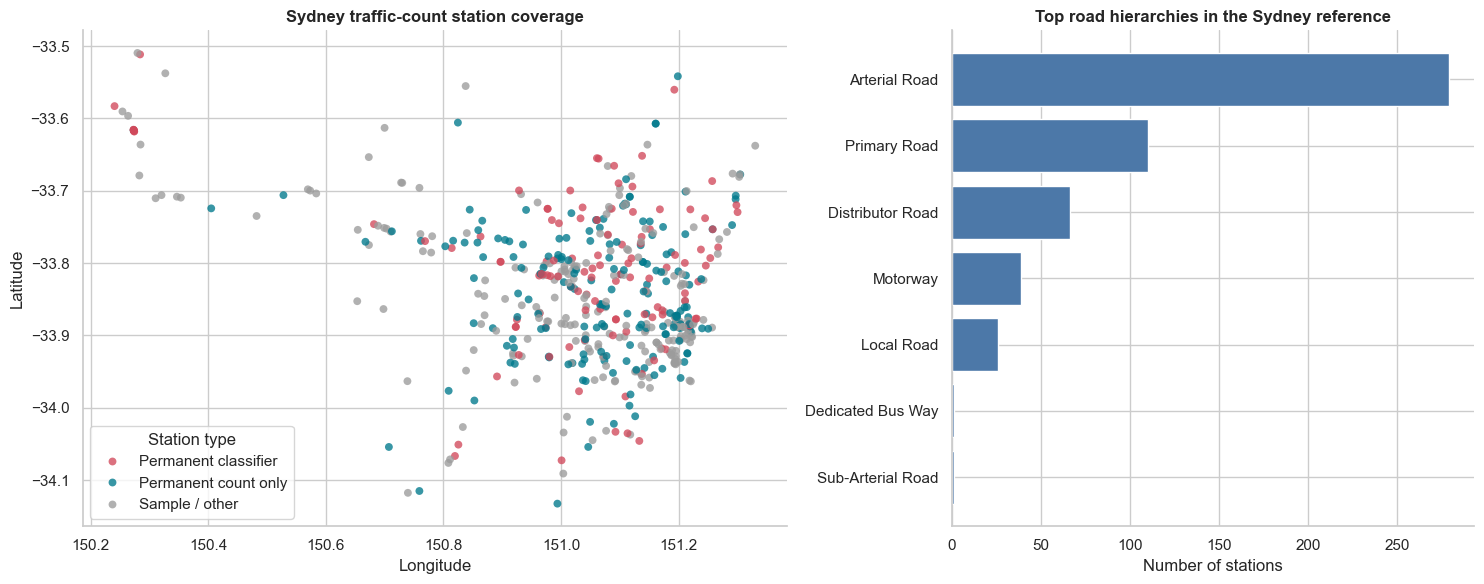

In [3]:
map_data = sydney_ref.dropna(subset=["wgs84_longitude", "wgs84_latitude"]).copy()
map_data["station_type"] = np.select(
    [
        map_data["permanent_station"].eq(1) & map_data["vehicle_classifier"].eq(1),
        map_data["permanent_station"].eq(1),
    ],
    ["Permanent classifier", "Permanent count only"],
    default="Sample / other",
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.35, 1]})
sns.scatterplot(
    data=map_data, x="wgs84_longitude", y="wgs84_latitude", hue="station_type",
    hue_order=["Permanent classifier", "Permanent count only", "Sample / other"],
    palette=["#D1495B", "#00798C", "#9C9C9C"], s=32, alpha=0.78, linewidth=0, ax=axes[0]
)
axes[0].set(title="Sydney traffic-count station coverage", xlabel="Longitude", ylabel="Latitude")
axes[0].legend(title="Station type", loc="best")

hierarchy = (
    sydney_ref["road_functional_hierarchy"].fillna("Unknown").value_counts().head(10).sort_values()
)
axes[1].barh(hierarchy.index, hierarchy.values, color="#4C78A8")
axes[1].set(title="Top road hierarchies in the Sydney reference", xlabel="Number of stations", ylabel="")
sns.despine(fig=fig)
plt.tight_layout()
plt.show()

## 2. Annual traffic trends

For each station, year, and vehicle class, directional counts are summed before comparing stations. The charts use median station values because a small number of very busy roads can dominate the mean. The partial 2026 year is excluded from trend charts.

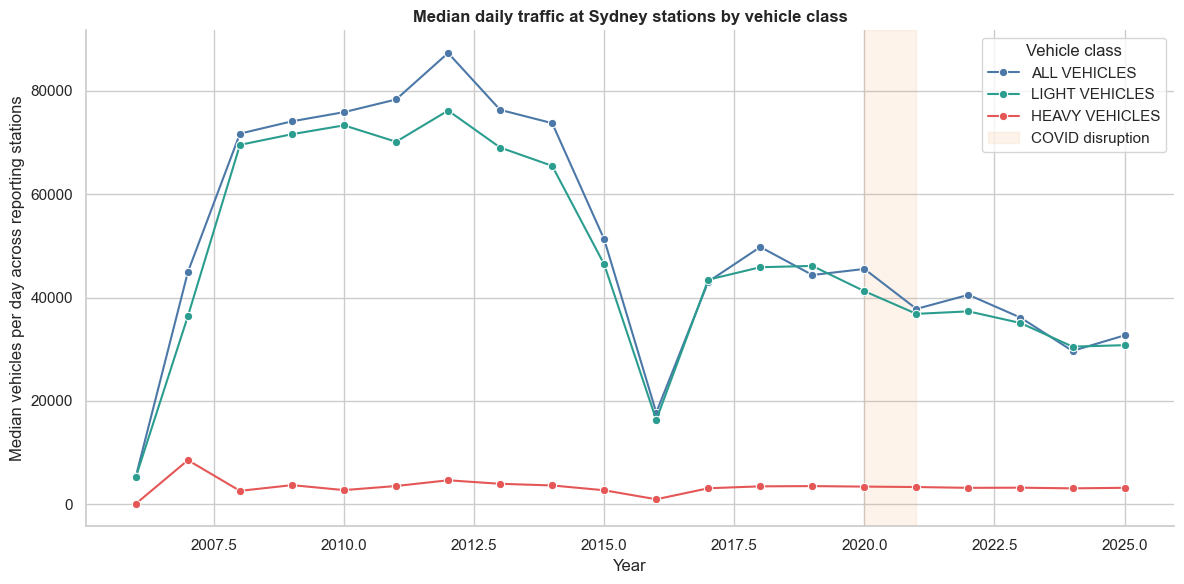

,year,classification_type,median_daily_traffic,stations
51,2023,ALL VEHICLES,36125.0,71
52,2023,HEAVY VEHICLES,3216.5,84
53,2023,LIGHT VEHICLES,35077.0,84
54,2024,ALL VEHICLES,29677.0,68
55,2024,HEAVY VEHICLES,3090.0,79
56,2024,LIGHT VEHICLES,30506.0,79
57,2025,ALL VEHICLES,32684.0,63
58,2025,HEAVY VEHICLES,3195.0,69
59,2025,LIGHT VEHICLES,30788.0,69


In [4]:
annual_complete = annual_sydney.loc[
    annual_sydney["period"].eq("ALL DAYS")
    & annual_sydney["year"].le(LAST_COMPLETE_YEAR)
    & annual_sydney["classification_type"].isin(["ALL VEHICLES", "LIGHT VEHICLES", "HEAVY VEHICLES"])
].copy()

station_year = (
    annual_complete.groupby(["station_id", "year", "classification_type"], as_index=False)["traffic_count"]
    .sum(min_count=1)
)
annual_summary = (
    station_year.groupby(["year", "classification_type"], as_index=False)
    .agg(median_daily_traffic=("traffic_count", "median"), stations=("station_id", "nunique"))
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=annual_summary, x="year", y="median_daily_traffic", hue="classification_type",
    hue_order=["ALL VEHICLES", "LIGHT VEHICLES", "HEAVY VEHICLES"],
    palette=["#4C78A8", "#2A9D8F", "#E45756"], marker="o", ax=ax
)
ax.axvspan(2020, 2021, color="#F4A261", alpha=0.12, label="COVID disruption")
ax.set(
    title="Median daily traffic at Sydney stations by vehicle class",
    xlabel="Year", ylabel="Median vehicles per day across reporting stations"
)
ax.legend(title="Vehicle class")
sns.despine()
plt.tight_layout()
plt.show()

display(annual_summary.tail(9))

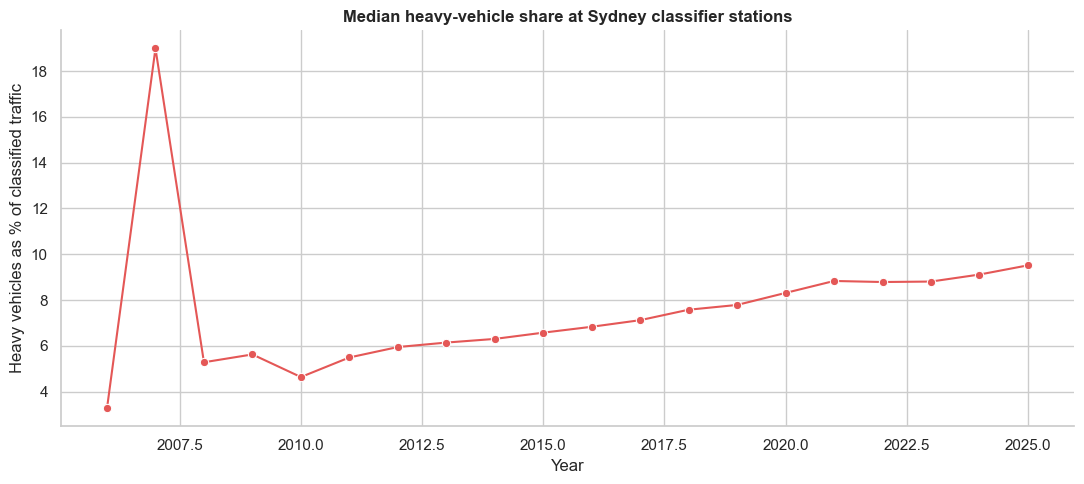

,year,median_heavy_share_pct,classified_stations
10,2016,6.832984,105
11,2017,7.121290,100
12,2018,7.577895,101
13,2019,7.786253,100
14,2020,8.311395,97
15,2021,8.833194,100
16,2022,8.787358,96
17,2023,8.807584,84
18,2024,9.114016,79
19,2025,9.515732,69


In [5]:
class_pivot = station_year.pivot_table(
    index=["station_id", "year"], columns="classification_type", values="traffic_count", aggfunc="sum"
).reset_index()
required = {"LIGHT VEHICLES", "HEAVY VEHICLES"}
if required.issubset(class_pivot.columns):
    denominator = class_pivot["LIGHT VEHICLES"] + class_pivot["HEAVY VEHICLES"]
    class_pivot["heavy_share_pct"] = 100 * class_pivot["HEAVY VEHICLES"] / denominator.replace(0, np.nan)
    heavy_summary = (
        class_pivot.groupby("year", as_index=False)
        .agg(median_heavy_share_pct=("heavy_share_pct", "median"), classified_stations=("heavy_share_pct", "count"))
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    sns.lineplot(data=heavy_summary, x="year", y="median_heavy_share_pct", color="#E45756", marker="o", ax=ax)
    ax.set(
        title="Median heavy-vehicle share at Sydney classifier stations",
        xlabel="Year", ylabel="Heavy vehicles as % of classified traffic"
    )
    sns.despine()
    plt.tight_layout()
    plt.show()
    display(heavy_summary.tail(10))
else:
    print("Light- and heavy-vehicle annual series were not both available.")

## 3. Hourly traffic profiles

Only selected years are aggregated, but all permanent CSV parts are scanned because rows are split across files. Blank hour cells are treated as zero only when calculating each day's hourly share; the quality table reports how often blanks occur and verifies whether available hourly values still sum to `daily_total`. This distinction should be revisited before model training because a blank can mean zero traffic or unavailable measurement depending on the source system.

In [6]:
HOUR_COLUMNS = [f"hour_{hour:02d}" for hour in range(24)]
DOW_LABELS = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}

def aggregate_hourly_profiles(paths, valid_station_keys, years, chunk_size=100_000):
    profile_sum = defaultdict(lambda: np.zeros(24, dtype=float))
    profile_n = defaultdict(lambda: np.zeros(24, dtype=np.int64))
    weekday_sum = defaultdict(lambda: np.zeros(24, dtype=float))
    weekday_n = defaultdict(lambda: np.zeros(24, dtype=np.int64))
    quality = defaultdict(lambda: {"rows": 0, "rows_with_blank_hours": 0, "blank_hour_cells": 0, "daily_total_mismatches": 0})
    usecols = ["station_key", "classification_seq", "year", "day_of_week", "daily_total", *HOUR_COLUMNS]

    for path in paths:
        kept_rows = 0
        for chunk in pd.read_csv(
            path, usecols=usecols, dtype={"station_key": "string"}, chunksize=chunk_size, low_memory=False
        ):
            chunk["year"] = pd.to_numeric(chunk["year"], errors="coerce")
            chunk["classification_seq"] = pd.to_numeric(chunk["classification_seq"], errors="coerce")
            chunk = chunk.loc[
                chunk["station_key"].isin(valid_station_keys)
                & chunk["year"].isin(years)
                & chunk["classification_seq"].isin(CLASS_LABELS)
            ].copy()
            if chunk.empty:
                continue

            kept_rows += len(chunk)
            hours = chunk[HOUR_COLUMNS].apply(pd.to_numeric, errors="coerce")
            daily_total = pd.to_numeric(chunk["daily_total"], errors="coerce")
            filled_hours = hours.fillna(0)
            hourly_sum = filled_hours.sum(axis=1)
            shares = filled_hours.div(daily_total.where(daily_total.gt(0)), axis=0) * 100

            for class_code, indices in chunk.groupby("classification_seq").groups.items():
                class_code = int(class_code)
                class_hours = hours.loc[indices]
                class_shares = shares.loc[indices]
                class_daily = daily_total.loc[indices]
                class_hourly_sum = hourly_sum.loc[indices]

                profile_sum[class_code] += class_shares.sum(axis=0, skipna=True).to_numpy()
                profile_n[class_code] += class_shares.notna().sum(axis=0).to_numpy()
                quality[class_code]["rows"] += len(indices)
                quality[class_code]["rows_with_blank_hours"] += int(class_hours.isna().any(axis=1).sum())
                quality[class_code]["blank_hour_cells"] += int(class_hours.isna().sum().sum())
                quality[class_code]["daily_total_mismatches"] += int(
                    (class_daily.sub(class_hourly_sum).abs().gt(0.001) & class_daily.notna()).sum()
                )

            light_mask = chunk["classification_seq"].eq(2)
            for day, indices in chunk.loc[light_mask].groupby("day_of_week").groups.items():
                day = int(day)
                day_shares = shares.loc[indices]
                weekday_sum[day] += day_shares.sum(axis=0, skipna=True).to_numpy()
                weekday_n[day] += day_shares.notna().sum(axis=0).to_numpy()

        print(f"{path.name}: retained {kept_rows:,} Sydney rows for {years}")

    profile_rows = []
    for class_code in sorted(profile_sum):
        mean_share = np.divide(
            profile_sum[class_code], profile_n[class_code],
            out=np.full(24, np.nan), where=profile_n[class_code] > 0
        )
        profile_rows.extend(
            {"classification": CLASS_LABELS[class_code], "hour": hour, "mean_daily_share_pct": value}
            for hour, value in enumerate(mean_share)
        )

    weekday_matrix = pd.DataFrame(index=range(1, 8), columns=range(24), dtype=float)
    for day in weekday_matrix.index:
        weekday_matrix.loc[day] = np.divide(
            weekday_sum[day], weekday_n[day],
            out=np.full(24, np.nan), where=weekday_n[day] > 0
        )
    weekday_matrix.index = [DOW_LABELS[day] for day in weekday_matrix.index]

    quality_rows = []
    for class_code, values in sorted(quality.items()):
        quality_rows.append({"classification": CLASS_LABELS[class_code], **values})

    return pd.DataFrame(profile_rows), weekday_matrix, pd.DataFrame(quality_rows)

hourly_profile, light_weekday_matrix, hourly_quality = aggregate_hourly_profiles(
    HOURLY_FILES, sydney_keys, HOURLY_YEARS, CHUNK_SIZE
)
display(hourly_quality)

road_traffic_counts_hourly_permanent0.csv: retained 3,499 Sydney rows for [2019, 2020, 2024, 2025]


road_traffic_counts_hourly_permanent1.csv: retained 79,305 Sydney rows for [2019, 2020, 2024, 2025]


road_traffic_counts_hourly_permanent2.csv: retained 0 Sydney rows for [2019, 2020, 2024, 2025]


road_traffic_counts_hourly_permanent3.csv: retained 247,949 Sydney rows for [2019, 2020, 2024, 2025]


road_traffic_counts_hourly_permanent4.csv: retained 292 Sydney rows for [2019, 2020, 2024, 2025]


,classification,rows,rows_with_blank_hours,blank_hour_cells,daily_total_mismatches
0,Unclassified vehicles,79286,5982,9246,0
1,Light vehicles,125946,22843,143516,0
2,Heavy vehicles,125813,35566,162760,0


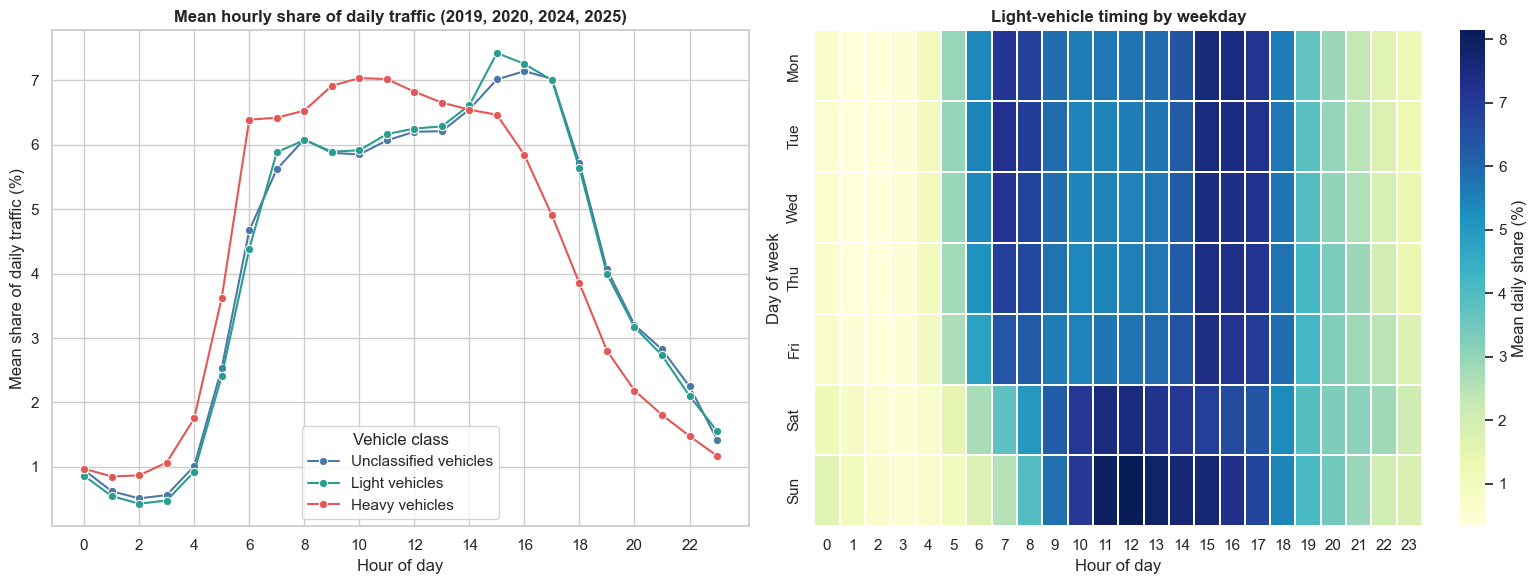

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1.1, 1.2]})
sns.lineplot(
    data=hourly_profile, x="hour", y="mean_daily_share_pct", hue="classification",
    palette=CLASS_COLORS, marker="o", ax=axes[0]
)
axes[0].set(
    title=f"Mean hourly share of daily traffic ({', '.join(map(str, HOURLY_YEARS))})",
    xlabel="Hour of day", ylabel="Mean share of daily traffic (%)", xticks=range(0, 24, 2)
)
axes[0].legend(title="Vehicle class")

sns.heatmap(
    light_weekday_matrix, cmap="YlGnBu", linewidths=0.25, cbar_kws={"label": "Mean daily share (%)"}, ax=axes[1]
)
axes[1].set(
    title="Light-vehicle timing by weekday", xlabel="Hour of day", ylabel="Day of week"
)
plt.tight_layout()
plt.show()

## 4. NSW fleet mix and combustion factors

Fleet composition helps convert light/heavy traffic counts into a more realistic vehicle mix. National Greenhouse Accounts factors convert fuel volume to direct combustion CO2-equivalent; they do **not** provide emissions per vehicle-kilometre. A complete target still needs distance, speed or congestion, fuel consumption, and vehicle technology assumptions.

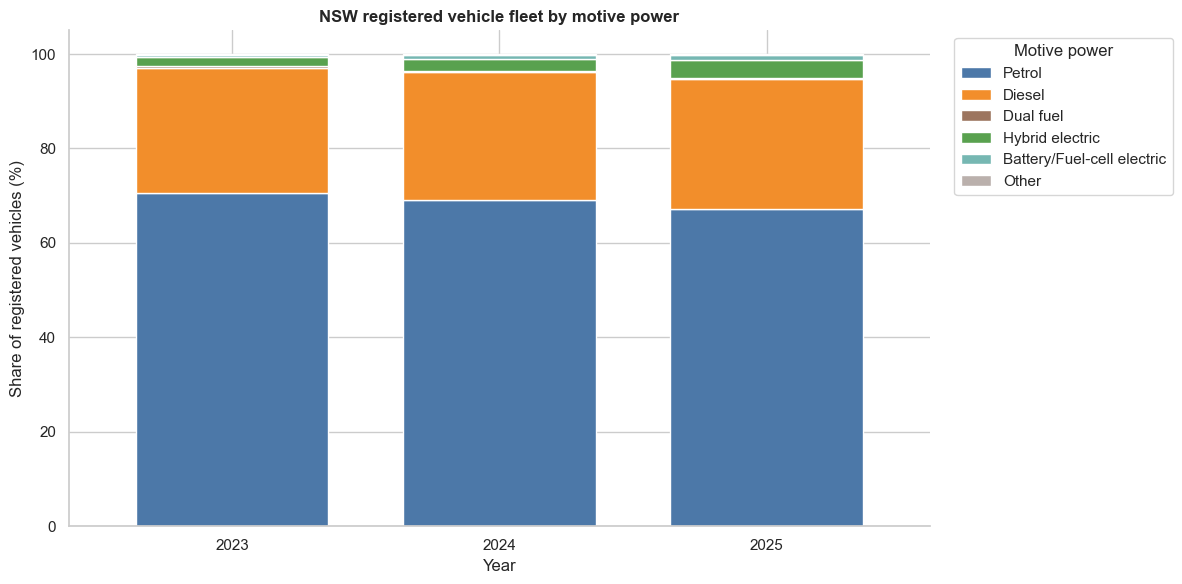

,Year,Petrol,Diesel,Dual fuel,Hybrid electric,Battery/Fuel-cell electric,Other,Total
10,2023,4342263,1637342,14719,125856,24789,10778,6155747
11,2024,4348041,1709896,12723,163948,52505,9533,6296646
12,2025,4310835,1762690,10904,236943,78317,8185,6407874


In [8]:
if FLEET_FILE.exists():
    fleet_raw = pd.read_excel(FLEET_FILE, sheet_name="Table 5", header=None)
    year_header_row = fleet_raw.apply(
        lambda row: row.astype(str).str.strip().eq("Year").any(), axis=1
    ).idxmax()
    nsw_label_row = fleet_raw.apply(
        lambda row: row.astype(str).str.strip().eq("New South Wales").any(), axis=1
    ).idxmax()
    fleet_columns = fleet_raw.loc[year_header_row].dropna().astype(str).tolist()
    nsw_fleet = fleet_raw.loc[nsw_label_row + 1 : nsw_label_row + 3].dropna(axis=1, how="all").copy()
    nsw_fleet.columns = fleet_columns
    nsw_fleet["Year"] = pd.to_numeric(nsw_fleet["Year"], errors="coerce").astype("Int64")
    fuel_columns = [column for column in fleet_columns if column not in {"Year", "Total"}]
    nsw_fleet[fuel_columns + ["Total"]] = nsw_fleet[fuel_columns + ["Total"]].apply(pd.to_numeric, errors="coerce")
    fleet_share = nsw_fleet.set_index("Year")[fuel_columns].div(nsw_fleet.set_index("Year")["Total"], axis=0) * 100

    colors = ["#4C78A8", "#F28E2B", "#9C755F", "#59A14F", "#76B7B2", "#BAB0AC"]
    ax = fleet_share.plot(kind="bar", stacked=True, figsize=(12, 6), color=colors, width=0.72)
    ax.set(title="NSW registered vehicle fleet by motive power", xlabel="Year", ylabel="Share of registered vehicles (%)")
    ax.legend(title="Motive power", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.tick_params(axis="x", rotation=0)
    sns.despine()
    plt.tight_layout()
    plt.show()
    display(nsw_fleet)
else:
    print(f"Optional fleet workbook not found: {FLEET_FILE}")

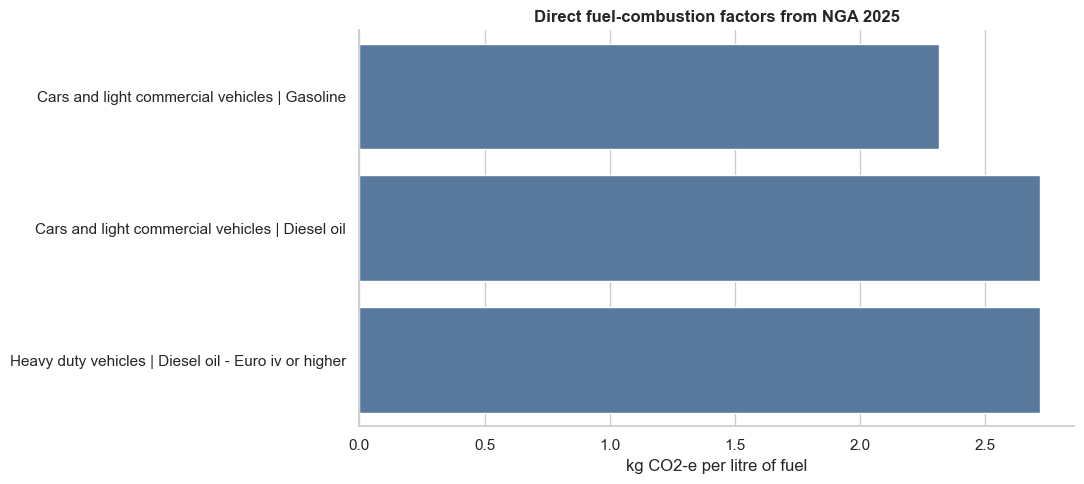

,transport_type,fuel,direct_kg_co2e_per_litre
4,Cars and light commercial vehicles,Gasoline,2.312604
5,Cars and light commercial vehicles,Diesel oil,2.717826
16,Heavy duty vehicles,Diesel oil - Euro iv or higher,2.716282


In [9]:
if FACTOR_FILE.exists():
    factor_raw = pd.read_excel(FACTOR_FILE, sheet_name="Table 9", header=None)
    factors = factor_raw.iloc[4:, :8].copy()
    factors.columns = [
        "transport_type", "fuel", "energy_gj_per_kl", "co2_kg_per_gj",
        "ch4_kg_co2e_per_gj", "n2o_kg_co2e_per_gj", "combined_kg_co2e_per_gj", "scope3_kg_co2e_per_gj"
    ]
    for column in ["energy_gj_per_kl", "combined_kg_co2e_per_gj"]:
        factors[column] = pd.to_numeric(factors[column], errors="coerce")
    factors["direct_kg_co2e_per_litre"] = (
        factors["energy_gj_per_kl"] * factors["combined_kg_co2e_per_gj"] / 1000
    )
    selected_factors = factors.loc[
        ((factors["transport_type"] == "Cars and light commercial vehicles") & factors["fuel"].isin(["Gasoline", "Diesel oil"]))
        | ((factors["transport_type"] == "Heavy duty vehicles") & factors["fuel"].astype(str).str.contains("Diesel oil - Euro iv", case=False, na=False))
    ].copy()
    selected_factors["scenario"] = selected_factors["transport_type"] + " | " + selected_factors["fuel"]

    fig, ax = plt.subplots(figsize=(11, 5))
    sns.barplot(data=selected_factors, y="scenario", x="direct_kg_co2e_per_litre", color="#4C78A8", ax=ax)
    ax.set(
        title="Direct fuel-combustion factors from NGA 2025",
        xlabel="kg CO2-e per litre of fuel", ylabel=""
    )
    sns.despine()
    plt.tight_layout()
    plt.show()
    display(selected_factors[["transport_type", "fuel", "direct_kg_co2e_per_litre"]])
else:
    print(f"Optional greenhouse-factor workbook not found: {FACTOR_FILE}")

## 5. What is useful for the emissions model?

**Strong traffic features already available**

- Light-vehicle count and heavy-vehicle count, kept separate because their fuel use and emissions differ.
- Hour, weekday, month, public-holiday and school-holiday indicators.
- Station location, road hierarchy, lane count, direction and local government area.
- Lagged traffic, rolling averages, peak-period indicators and heavy-vehicle share.

**Additional data needed for a defensible target**

- Road-segment length or vehicle-kilometres travelled.
- Average speed, congestion or travel-time data; stop-start driving changes emission rates.
- Fleet composition by vehicle age, fuel and technology, ideally by area and year.
- Emission rates in grams per vehicle-kilometre by vehicle class and operating condition.
- Weather if the objective includes air pollutant concentrations rather than emitted mass.

A practical first target is **estimated kg CO2-e per station-hour**: `vehicle count x represented distance x class-specific kg CO2-e per vehicle-km`, adjusted by fleet mix and speed. If this target is constructed directly from traffic counts, those same counts should not be presented as evidence that the model independently discovered emissions; the result is an emissions estimator or surrogate model. Independent roadside or inventory measurements are preferable for validation.